# **Import Library**

In [ ]:
# ============================================
# IMPORT LIBRARY
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# **Load dataset dan info basic dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df_train = pd.read_csv('/content/drive/MyDrive/python/data_dummy_bantuan_nelayan_25.csv')
df_train

Mounted at /content/drive


,ID_Nelayan,Provinsi,Jenis_Alat_Tangkap,Usia,Lama_Usaha_Tahun,Frekuensi_Melaut_Bulan,Durasi_Melaut_Hari,Hasil_Tangkapan_Ton_Bulan,Pendapatan_Ribu_Bulan,Jarak_Domisili_Kantor_Km,Kelengkapan_Dokumen_Persen,Status_KUSUKA,Pernah_Verifikasi_Lapangan,Perlu_Verifikasi,Label_Perlu_Verifikasi,Probabilitas_Perlu_Verifikasi
0,NLN00001,Bali,Pancing Cumi,48,4.7,20,3.2,0.76,2517,39.6,91.4,Padan,Tidak,1,Ya,0.230
1,NLN00002,Jawa Barat,Jaring Insang,46,6.1,20,1.0,1.83,3804,10.5,100.0,Padan,Tidak,0,Tidak,0.096
2,NLN00003,Maluku Utara,Bubu,37,5.4,24,3.9,0.40,3152,6.3,66.6,Padan,Tidak,0,Tidak,0.344
3,NLN00004,Sulawesi Utara,Bubu,36,13.0,10,3.5,0.40,1927,5.5,100.0,Belum Padan,Ya,0,Tidak,0.099
4,NLN00005,NTB,Pukat Cincin,43,12.9,10,4.8,1.69,11540,24.3,86.3,Padan,Ya,0,Tidak,0.105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,NLN00996,NTB,Pancing Ulur,43,4.4,11,2.9,0.74,3128,17.6,73.0,Padan,Ya,0,Tidak,0.177
996,NLN00997,Maluku,Bubu,40,6.6,13,7.3,0.39,1134,13.7,93.7,Padan,Ya,0,Tidak,0.057
997,NLN00998,Papua Barat,Jaring Insang,45,7.5,7,2.9,0.40,4123,11.1,81.1,Padan,Ya,0,Tidak,0.113
998,NLN00999,Bali,Pancing Cumi,51,6.5,8,1.0,1.56,800,17.1,68.9,Belum Padan,Ya,0,Tidak,0.494


# **Exploratory Data Analysis (EDA)**

## Data Cleanning & Analysis

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID_Nelayan                     1000 non-null   object 
 1   Provinsi                       1000 non-null   object 
 2   Jenis_Alat_Tangkap             1000 non-null   object 
 3   Usia                           1000 non-null   int64  
 4   Lama_Usaha_Tahun               1000 non-null   float64
 5   Frekuensi_Melaut_Bulan         1000 non-null   int64  
 6   Durasi_Melaut_Hari             1000 non-null   float64
 7   Hasil_Tangkapan_Ton_Bulan      1000 non-null   float64
 8   Pendapatan_Ribu_Bulan          1000 non-null   int64  
 9   Jarak_Domisili_Kantor_Km       1000 non-null   float64
 10  Kelengkapan_Dokumen_Persen     1000 non-null   float64
 11  Status_KUSUKA                  1000 non-null   object 
 12  Pernah_Verifikasi_Lapangan     1000 non-null   ob

In [ ]:
df_train.isna().value_counts()

,,,,,,,,,,,,,,,,count
ID_Nelayan,Provinsi,Jenis_Alat_Tangkap,Usia,Lama_Usaha_Tahun,Frekuensi_Melaut_Bulan,Durasi_Melaut_Hari,Hasil_Tangkapan_Ton_Bulan,Pendapatan_Ribu_Bulan,Jarak_Domisili_Kantor_Km,Kelengkapan_Dokumen_Persen,Status_KUSUKA,Pernah_Verifikasi_Lapangan,Perlu_Verifikasi,Label_Perlu_Verifikasi,Probabilitas_Perlu_Verifikasi,
False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1000


In [ ]:
mv=df_train.isna().sum()
# Menampilkan hasil
print("Jumlah missing values dari masing-masing variabel:")
print(mv[mv > 0])

Jumlah missing values dari masing-masing variabel:
Series([], dtype: int64)


In [ ]:
df_train.columns

Index(['ID_Nelayan', 'Provinsi', 'Jenis_Alat_Tangkap', 'Usia',
       'Lama_Usaha_Tahun', 'Frekuensi_Melaut_Bulan', 'Durasi_Melaut_Hari',
       'Hasil_Tangkapan_Ton_Bulan', 'Pendapatan_Ribu_Bulan',
       'Jarak_Domisili_Kantor_Km', 'Kelengkapan_Dokumen_Persen',
       'Status_KUSUKA', 'Pernah_Verifikasi_Lapangan', 'Perlu_Verifikasi',
       'Label_Perlu_Verifikasi', 'Probabilitas_Perlu_Verifikasi'],
      dtype='object')

In [ ]:
print (df_train.describe())

              Usia  Lama_Usaha_Tahun  Frekuensi_Melaut_Bulan  \
count  1000.000000       1000.000000             1000.000000   
mean     43.511000          8.901000               12.053000   
std       9.857842          5.605831                4.885085   
min      20.000000          0.500000                1.000000   
25%      37.000000          4.800000                9.000000   
50%      43.000000          7.800000               12.000000   
75%      50.000000         11.600000               15.000000   
max      70.000000         35.000000               25.000000   

       Durasi_Melaut_Hari  Hasil_Tangkapan_Ton_Bulan  Pendapatan_Ribu_Bulan  \
count          1000.00000                1000.000000            1000.000000   
mean              4.40820                   1.101070            3497.423000   
std               1.76921                   0.823572            2087.954794   
min               1.00000                   0.110000             800.000000   
25%               3.20000   

In [ ]:
df_train.describe()

,Usia,Lama_Usaha_Tahun,Frekuensi_Melaut_Bulan,Durasi_Melaut_Hari,Hasil_Tangkapan_Ton_Bulan,Pendapatan_Ribu_Bulan,Jarak_Domisili_Kantor_Km,Kelengkapan_Dokumen_Persen,Perlu_Verifikasi,Probabilitas_Perlu_Verifikasi
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,43.511000,8.901000,12.053000,4.40820,1.101070,3497.423000,18.279400,81.008400,0.24900,0.240251
std,9.857842,5.605831,4.885085,1.76921,0.823572,2087.954794,12.197675,13.143155,0.43265,0.164195
min,20.000000,0.500000,1.000000,1.00000,0.110000,800.000000,0.500000,30.000000,0.00000,0.027000
25%,37.000000,4.800000,9.000000,3.20000,0.550000,2010.500000,9.600000,71.700000,0.00000,0.110750
50%,43.000000,7.800000,12.000000,4.40000,0.880000,2966.500000,15.500000,82.000000,0.00000,0.202000
75%,50.000000,11.600000,15.000000,5.60000,1.390000,4401.250000,24.100000,91.225000,0.00000,0.327250
max,70.000000,35.000000,25.000000,10.10000,7.430000,18070.000000,77.300000,100.000000,1.00000,0.863000


In [ ]:
# ============================================================
# 3. DEFINISIKAN TARGET DAN FEATURES
# ============================================================

target = "Perlu_Verifikasi"

features = [
    "Usia",
    "Lama_Usaha_Tahun",
    "Frekuensi_Melaut_Bulan",
    "Durasi_Melaut_Hari",
    "Hasil_Tangkapan_Ton_Bulan",
    "Pendapatan_Ribu_Bulan",
    "Jarak_Domisili_Kantor_Km",
    "Kelengkapan_Dokumen_Persen",
    "Status_KUSUKA",
    "Pernah_Verifikasi_Lapangan"
]

X = df_train[features]
y = df_train[target]

print("Features:")
print(X.columns.tolist())

print("\nDistribusi target:")
print(y.value_counts())

print("\nProporsi target:")
print(y.value_counts(normalize=True))

Features:
['Usia', 'Lama_Usaha_Tahun', 'Frekuensi_Melaut_Bulan', 'Durasi_Melaut_Hari', 'Hasil_Tangkapan_Ton_Bulan', 'Pendapatan_Ribu_Bulan', 'Jarak_Domisili_Kantor_Km', 'Kelengkapan_Dokumen_Persen', 'Status_KUSUKA', 'Pernah_Verifikasi_Lapangan']

Distribusi target:
Perlu_Verifikasi
0    751
1    249
Name: count, dtype: int64

Proporsi target:
Perlu_Verifikasi
0    0.751
1    0.249
Name: proportion, dtype: float64


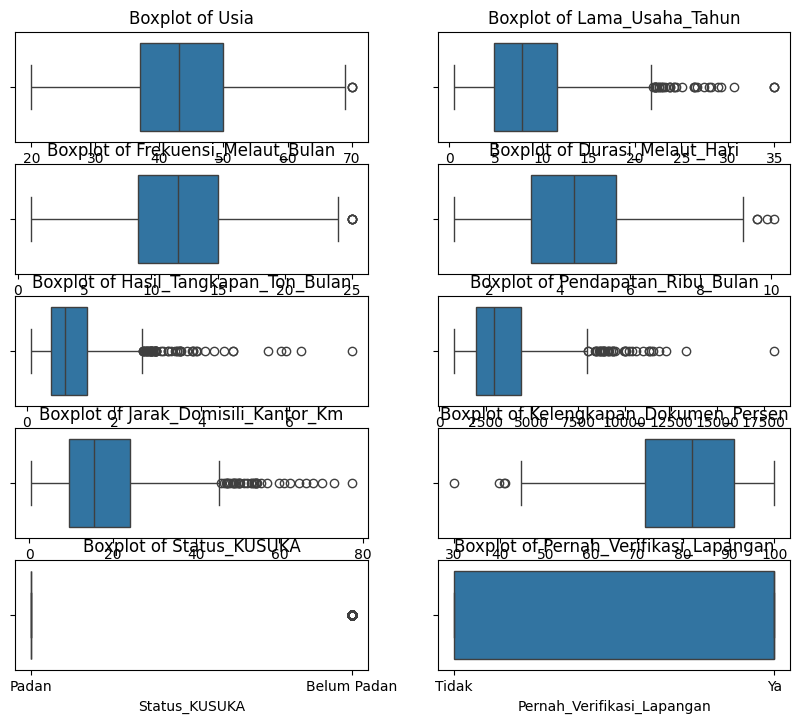

In [ ]:
plt.figure(figsize=(10, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(6, 2, i)
    sns.boxplot(data=df_train, x=feature)
    plt.title(f'Boxplot of {feature}')

In [ ]:
import pandas as pd
import numpy as np

# Fungsi untuk mendeteksi outlier menggunakan metode IQR
def detect_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]
outlier_counts = {}
# Hanya iterasi pada kolom numerik
for col in df_train.select_dtypes(include=['number']):
    outliers = detect_outliers(df_train[col])
    outlier_counts[col] = outliers.count()
    print(f"{col}: {outlier_counts[col]} outlier")

Usia: 3 outlier
Lama_Usaha_Tahun: 33 outlier
Frekuensi_Melaut_Bulan: 5 outlier
Durasi_Melaut_Hari: 4 outlier
Hasil_Tangkapan_Ton_Bulan: 58 outlier
Pendapatan_Ribu_Bulan: 40 outlier
Jarak_Domisili_Kantor_Km: 37 outlier
Kelengkapan_Dokumen_Persen: 4 outlier
Perlu_Verifikasi: 249 outlier
Probabilitas_Perlu_Verifikasi: 26 outlier


#**Train-Test Split**

In [ ]:
# ============================================================
# 4. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (800, 10)
Testing : (200, 10)


In [ ]:
# ============================================================
# 5. IDENTIFIKASI TIPE FEATURE
# ============================================================

numeric_features = [
    "Usia",
    "Lama_Usaha_Tahun",
    "Frekuensi_Melaut_Bulan",
    "Durasi_Melaut_Hari",
    "Hasil_Tangkapan_Ton_Bulan",
    "Pendapatan_Ribu_Bulan",
    "Jarak_Domisili_Kantor_Km",
    "Kelengkapan_Dokumen_Persen"
]

categorical_features = [
    "Status_KUSUKA",
    "Pernah_Verifikasi_Lapangan"
]

#**Preprocessing**

In [ ]:
# ============================================================
# 6. PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [ ]:
# ============================================================
# 7. DEFINISIKAN MODEL
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        ),

    "Naive Bayes":
        GaussianNB(),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
}

In [ ]:
# ============================================================
# 8. BUAT PIPELINE
# ============================================================

pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("model", model)
        ]
    )

#**Model**

## Logistic Regression

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [ ]:
model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("logistic_regression", logistic_model)
    ]
)

In [ ]:
model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['Usia', 'Lama_Usaha_Tahun',
                                                   'Frekuensi_Melaut_Bulan',
                                                   'Durasi_Melaut_Hari',
                                                   'Hasil_Tangkapan_Ton_Bulan',
                                                   'Pendapatan_Ribu_Bulan',
                                                   'Jarak_Domisili_Kantor_Km',
                                                   'Kelengkapan_Dokumen_Persen']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Status_KUSUKA',
                                                   'Pernah_Verifikasi_Lapangan'])])),
                ('logistic_regression',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
# PREDICTION
y_pred = model.predict(X_test)

hasil_prediksi = pd.DataFrame({
    "Actual": y_test.values,
    "Prediction": y_pred
})

display(hasil_prediksi.head(10))

,Actual,Prediction
0,0,0
1,1,0
2,1,0
3,1,0
4,0,0
5,0,0
6,1,0
7,1,0
8,0,0
9,0,0


In [ ]:
hasil_prediksi = pd.DataFrame({
    "Actual": y_test.values,
    "Prediction": y_pred
})

display(hasil_prediksi.head(10))

,Actual,Prediction
0,0,0
1,1,0
2,1,0
3,1,0
4,0,0
5,0,0
6,1,0
7,1,0
8,0,0
9,0,0


In [ ]:
y_probability = model.predict_proba(X_test)[:, 1]

In [ ]:
hasil_prediksi = pd.DataFrame({
    "Actual": y_test.values,
    "Prediction": y_pred,
    "Probability_Perlu_Verifikasi": y_probability
})

display(hasil_prediksi.head(10))

,Actual,Prediction,Probability_Perlu_Verifikasi
0,0,0,0.191602
1,1,0,0.230650
2,1,0,0.043839
3,1,0,0.475614
4,0,0,0.206780
5,0,0,0.066128
6,1,0,0.192027
7,1,0,0.264988
8,0,0,0.309904
9,0,0,0.303536


In [ ]:
# 8. EVALUATION

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy, 4))

precision = precision_score(
    y_test,
    y_pred,
    pos_label=1
)

print("Precision:", round(precision, 4))

recall = recall_score(
    y_test,
    y_pred,
    pos_label=1
)

print("Recall:", round(recall, 4))

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=1
)

print("F1-Score:", round(f1, 4))

auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", round(auc, 4))

Accuracy: 0.745
Precision: 0.4545
Recall: 0.1
F1-Score: 0.1639
ROC-AUC: 0.7197


In [ ]:
print("===== MODEL EVALUATION =====")

print(f"Accuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1-Score  : {f1:.3f}")
print(f"ROC-AUC   : {auc:.3f}")

===== MODEL EVALUATION =====
Accuracy  : 0.745
Precision : 0.455
Recall    : 0.100
F1-Score  : 0.164
ROC-AUC   : 0.720


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Tidak Perlu Verifikasi",
            "Perlu Verifikasi"
        ]
    )
)

                        precision    recall  f1-score   support

Tidak Perlu Verifikasi       0.76      0.96      0.85       150
      Perlu Verifikasi       0.45      0.10      0.16        50

              accuracy                           0.74       200
             macro avg       0.61      0.53      0.51       200
          weighted avg       0.69      0.74      0.68       200



In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[144   6]
 [ 45   5]]


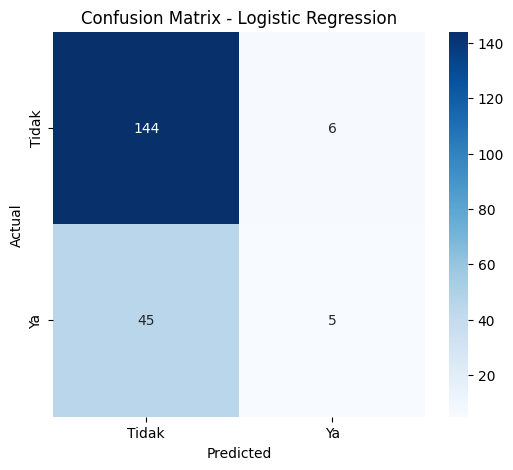

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Tidak",
        "Ya"
    ],
    yticklabels=[
        "Tidak",
        "Ya"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

## Decision Tree ##

DECISION TREE
Accuracy  : 0.625
Precision : 0.273
Recall    : 0.300
F1-Score  : 0.286
ROC-AUC   : 0.517

Classification Report:
                        precision    recall  f1-score   support

Tidak Perlu Verifikasi       0.76      0.73      0.75       150
      Perlu Verifikasi       0.27      0.30      0.29        50

              accuracy                           0.62       200
             macro avg       0.52      0.52      0.52       200
          weighted avg       0.64      0.62      0.63       200



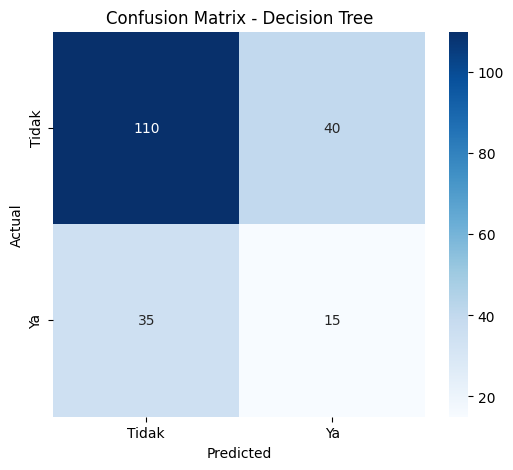

In [ ]:
model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "decision_tree",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)


# 6. TRAINING
model.fit(
    X_train,
    y_train
)


# 7. PREDICTION
y_pred = model.predict(X_test)

y_probability = model.predict_proba(
    X_test
)[:, 1]


# 8. EVALUATION
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_test,
    y_probability
)


print("================================")
print("DECISION TREE")
print("================================")

print(f"Accuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1-Score  : {f1:.3f}")
print(f"ROC-AUC   : {auc:.3f}")


# 9. CLASSIFICATION REPORT
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Tidak Perlu Verifikasi",
            "Perlu Verifikasi"
        ]
    )
)


# 10. CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Tidak", "Ya"],
    yticklabels=["Tidak", "Ya"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix - Decision Tree"
)

plt.show()

## Random Forest


RANDOM FOREST EVALUATION
Accuracy  : 0.730
Precision : 0.400
Recall    : 0.160
F1-Score  : 0.229
ROC-AUC   : 0.637

Classification Report:
                        precision    recall  f1-score   support

Tidak Perlu Verifikasi       0.77      0.92      0.84       150
      Perlu Verifikasi       0.40      0.16      0.23        50

              accuracy                           0.73       200
             macro avg       0.58      0.54      0.53       200
          weighted avg       0.68      0.73      0.68       200



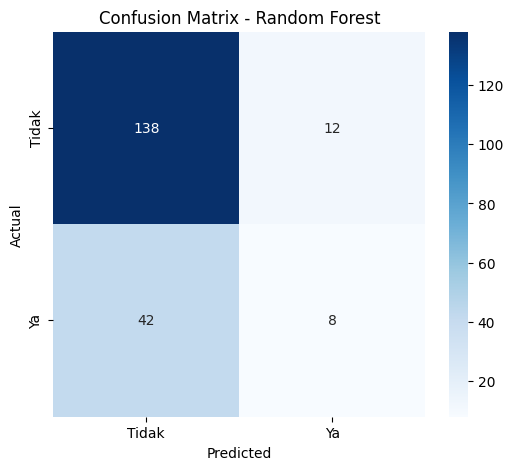

,Feature,Importance
7,numeric__Kelengkapan_Dokumen_Persen,0.160431
6,numeric__Jarak_Domisili_Kantor_Km,0.122081
5,numeric__Pendapatan_Ribu_Bulan,0.107851
1,numeric__Lama_Usaha_Tahun,0.107038
4,numeric__Hasil_Tangkapan_Ton_Bulan,0.104431
0,numeric__Usia,0.104114
3,numeric__Durasi_Melaut_Hari,0.100196
2,numeric__Frekuensi_Melaut_Bulan,0.087301
9,categorical__Status_KUSUKA_Padan,0.033738
8,categorical__Status_KUSUKA_Belum Padan,0.029754


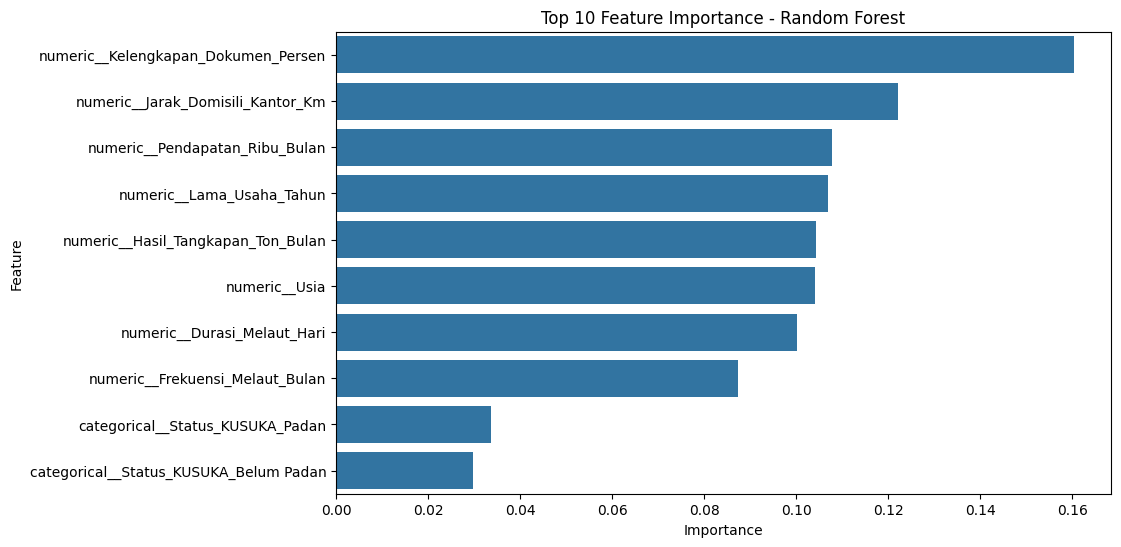

In [ ]:
model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),

        (
            "random_forest",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)


# ============================================
# 6. TRAINING
# ============================================

model.fit(
    X_train,
    y_train
)


# ============================================
# 7. PREDICTION
# ============================================

y_pred = model.predict(
    X_test
)

y_probability = model.predict_proba(
    X_test
)[:, 1]


# ============================================
# 8. EVALUATION
# ============================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_test,
    y_probability
)


print("\n====================================")
print("RANDOM FOREST EVALUATION")
print("====================================")

print(
    f"Accuracy  : {accuracy:.3f}"
)

print(
    f"Precision : {precision:.3f}"
)

print(
    f"Recall    : {recall:.3f}"
)

print(
    f"F1-Score  : {f1:.3f}"
)

print(
    f"ROC-AUC   : {auc:.3f}"
)


# ============================================
# 9. CLASSIFICATION REPORT
# ============================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Tidak Perlu Verifikasi",
            "Perlu Verifikasi"
        ],
        zero_division=0
    )
)


# ============================================
# 10. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Tidak",
        "Ya"
    ],
    yticklabels=[
        "Tidak",
        "Ya"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix - Random Forest"
)

plt.show()


# ============================================
# 11. FEATURE IMPORTANCE
# ============================================

rf = model.named_steps[
    "random_forest"
]

preprocessor_fitted = model.named_steps[
    "preprocessing"
]

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(
    feature_importance.head(15)
)


# ============================================
# 12. VISUAL FEATURE IMPORTANCE
# ============================================

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Feature Importance - Random Forest"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.show()

## KNN


KNN EVALUATION
Accuracy  : 0.730
Precision : 0.409
Recall    : 0.180
F1-Score  : 0.250
ROC-AUC   : 0.653

Classification Report:
                        precision    recall  f1-score   support

Tidak Perlu Verifikasi       0.77      0.91      0.84       150
      Perlu Verifikasi       0.41      0.18      0.25        50

              accuracy                           0.73       200
             macro avg       0.59      0.55      0.54       200
          weighted avg       0.68      0.73      0.69       200



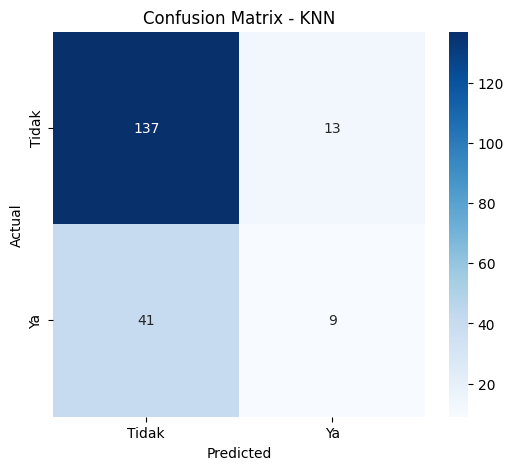

In [ ]:
model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),

        (
            "knn",
            KNeighborsClassifier(
                n_neighbors=5
            )
        )
    ]
)


# ============================================
# 7. TRAINING
# ============================================

model.fit(
    X_train,
    y_train
)


# ============================================
# 8. PREDICTION
# ============================================

y_pred = model.predict(
    X_test
)

y_probability = model.predict_proba(
    X_test
)[:, 1]


# ============================================
# 9. EVALUATION
# ============================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_test,
    y_probability
)


print("\n====================================")
print("KNN EVALUATION")
print("====================================")

print(
    f"Accuracy  : {accuracy:.3f}"
)

print(
    f"Precision : {precision:.3f}"
)

print(
    f"Recall    : {recall:.3f}"
)

print(
    f"F1-Score  : {f1:.3f}"
)

print(
    f"ROC-AUC   : {auc:.3f}"
)


# ============================================
# 10. CLASSIFICATION REPORT
# ============================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Tidak Perlu Verifikasi",
            "Perlu Verifikasi"
        ],
        zero_division=0
    )
)


# ============================================
# 11. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Tidak",
        "Ya"
    ],
    yticklabels=[
        "Tidak",
        "Ya"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix - KNN"
)

plt.show()

## SVM


Model SVM selesai dilatih.

SVM MODEL EVALUATION
Accuracy  : 0.745
Precision : 0.400
Recall    : 0.040
F1-Score  : 0.073
ROC-AUC   : 0.663

Classification Report:
                        precision    recall  f1-score   support

Tidak Perlu Verifikasi       0.75      0.98      0.85       150
      Perlu Verifikasi       0.40      0.04      0.07        50

              accuracy                           0.74       200
             macro avg       0.58      0.51      0.46       200
          weighted avg       0.67      0.74      0.66       200


Confusion Matrix:
[[147   3]
 [ 48   2]]


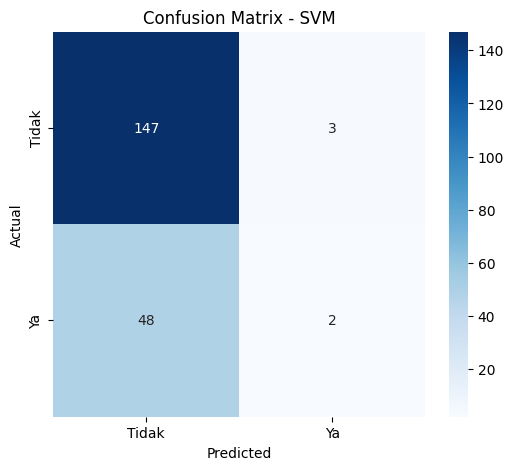

In [ ]:
# ============================================
# 6. SVM MODEL
# ============================================

model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "svm",
            SVC(
                kernel="rbf",
                probability=True,
                random_state=42
            )
        )
    ]
)


# ============================================
# 7. TRAINING
# ============================================

model.fit(
    X_train,
    y_train
)

print("\nModel SVM selesai dilatih.")


# ============================================
# 8. PREDICTION
# ============================================

y_pred = model.predict(
    X_test
)


# ============================================
# 9. PROBABILITY
# ============================================

y_probability = model.predict_proba(
    X_test
)[:, 1]


# ============================================
# 10. EVALUATION
# ============================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_test,
    y_probability
)


# ============================================
# 11. PRINT METRICS
# ============================================

print("\n====================================")
print("SVM MODEL EVALUATION")
print("====================================")

print(
    f"Accuracy  : {accuracy:.3f}"
)

print(
    f"Precision : {precision:.3f}"
)

print(
    f"Recall    : {recall:.3f}"
)

print(
    f"F1-Score  : {f1:.3f}"
)

print(
    f"ROC-AUC   : {auc:.3f}"
)


# ============================================
# 12. CLASSIFICATION REPORT
# ============================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Tidak Perlu Verifikasi",
            "Perlu Verifikasi"
        ],
        zero_division=0
    )
)


# ============================================
# 13. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ============================================
# 14. VISUALISASI
# ============================================

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Tidak",
        "Ya"
    ],
    yticklabels=[
        "Tidak",
        "Ya"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix - SVM"
)

plt.show()

## Naive Bayes


Model Naive Bayes selesai dilatih.

NAIVE BAYES MODEL EVALUATION
Accuracy  : 0.710
Precision : 0.409
Recall    : 0.360
F1-Score  : 0.383
ROC-AUC   : 0.685

Classification Report:
                        precision    recall  f1-score   support

Tidak Perlu Verifikasi       0.79      0.83      0.81       150
      Perlu Verifikasi       0.41      0.36      0.38        50

              accuracy                           0.71       200
             macro avg       0.60      0.59      0.60       200
          weighted avg       0.70      0.71      0.70       200


Confusion Matrix:
[[124  26]
 [ 32  18]]


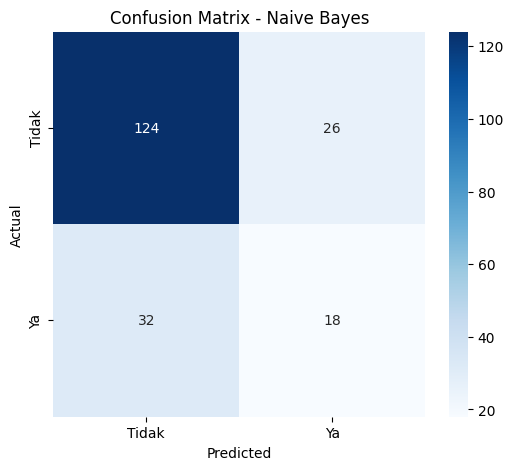

In [ ]:
model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),

        (
            "naive_bayes",
            GaussianNB()
        )
    ]
)


# ============================================
# 8. TRAINING
# ============================================

model.fit(
    X_train,
    y_train
)

print(
    "\nModel Naive Bayes selesai dilatih."
)


# ============================================
# 9. PREDICTION
# ============================================

y_pred = model.predict(
    X_test
)


# ============================================
# 10. PROBABILITY
# ============================================

y_probability = model.predict_proba(
    X_test
)[:, 1]


# ============================================
# 11. EVALUATION
# ============================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_test,
    y_probability
)


# ============================================
# 12. PRINT METRICS
# ============================================

print("\n====================================")
print("NAIVE BAYES MODEL EVALUATION")
print("====================================")

print(
    f"Accuracy  : {accuracy:.3f}"
)

print(
    f"Precision : {precision:.3f}"
)

print(
    f"Recall    : {recall:.3f}"
)

print(
    f"F1-Score  : {f1:.3f}"
)

print(
    f"ROC-AUC   : {auc:.3f}"
)


# ============================================
# 13. CLASSIFICATION REPORT
# ============================================

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Tidak Perlu Verifikasi",
            "Perlu Verifikasi"
        ],
        zero_division=0
    )
)


# ============================================
# 14. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print(
    "\nConfusion Matrix:"
)

print(cm)


# ============================================
# 15. VISUALISASI CONFUSION MATRIX
# ============================================

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Tidak",
        "Ya"
    ],
    yticklabels=[
        "Tidak",
        "Ya"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix - Naive Bayes"
)

plt.show()

## Gradient Boosting


Model Gradient Boosting selesai dilatih.

GRADIENT BOOSTING MODEL EVALUATION
Accuracy  : 0.760
Precision : 0.571
Recall    : 0.160
F1-Score  : 0.250
ROC-AUC   : 0.648

Classification Report:
                        precision    recall  f1-score   support

Tidak Perlu Verifikasi       0.77      0.96      0.86       150
      Perlu Verifikasi       0.57      0.16      0.25        50

              accuracy                           0.76       200
             macro avg       0.67      0.56      0.55       200
          weighted avg       0.72      0.76      0.71       200


Confusion Matrix:
[[144   6]
 [ 42   8]]


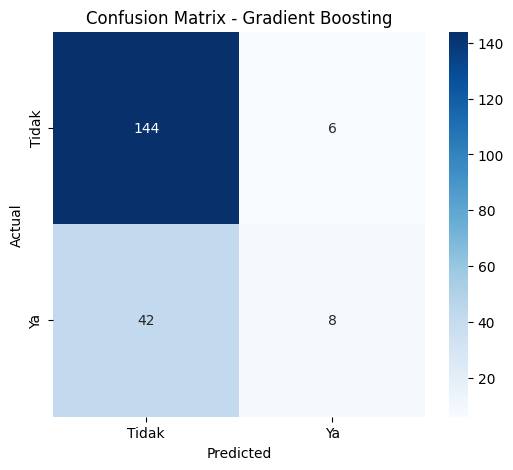

In [ ]:
# ============================================
# 6. PREPROCESSING
# ============================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)


# ============================================
# 7. GRADIENT BOOSTING MODEL
# ============================================

model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),

        (
            "gradient_boosting",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            )
        )
    ]
)


# ============================================
# 8. TRAINING
# ============================================

model.fit(
    X_train,
    y_train
)

print(
    "\nModel Gradient Boosting selesai dilatih."
)


# ============================================
# 9. PREDICTION
# ============================================

y_pred = model.predict(
    X_test
)


# ============================================
# 10. PROBABILITY
# ============================================

y_probability = model.predict_proba(
    X_test
)[:, 1]


# ============================================
# 11. EVALUATION
# ============================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_test,
    y_probability
)


# ============================================
# 12. PRINT METRICS
# ============================================

print("\n====================================")
print("GRADIENT BOOSTING MODEL EVALUATION")
print("====================================")

print(
    f"Accuracy  : {accuracy:.3f}"
)

print(
    f"Precision : {precision:.3f}"
)

print(
    f"Recall    : {recall:.3f}"
)

print(
    f"F1-Score  : {f1:.3f}"
)

print(
    f"ROC-AUC   : {auc:.3f}"
)


# ============================================
# 13. CLASSIFICATION REPORT
# ============================================

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Tidak Perlu Verifikasi",
            "Perlu Verifikasi"
        ],
        zero_division=0
    )
)


# ============================================
# 14. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print(
    "\nConfusion Matrix:"
)

print(cm)


# ============================================
# 15. VISUALISASI
# ============================================

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Tidak",
        "Ya"
    ],
    yticklabels=[
        "Tidak",
        "Ya"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix - Gradient Boosting"
)

plt.show()

# **Summary Model**

In [ ]:
# ============================================================
# 8. BUAT PIPELINE
# ============================================================

pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("model", model)
        ]
    )

# ============================================================
# 9. TRAINING SEMUA MODEL
# ============================================================

for name, pipeline in pipelines.items():

    print(f"Training {name}...")

    pipeline.fit(
        X_train,
        y_train
    )

print("\nSemua model selesai dilatih.")

# ============================================================
# 10. EVALUASI MODEL
# ============================================================

results = []

for name, pipeline in pipelines.items():

    y_pred = pipeline.predict(X_test)

    # Probability
    if hasattr(pipeline, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    })

results_df = pd.DataFrame(results)

display(results_df)

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training KNN...
Training SVM...
Training Naive Bayes...
Training Gradient Boosting...

Semua model selesai dilatih.


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Logistic Regression,0.745,0.454545,0.10,0.163934,0.719733
1,Decision Tree,0.705,0.384615,0.30,0.337079,0.581333
2,Random Forest,0.745,0.466667,0.14,0.215385,0.659733
3,KNN,0.730,0.409091,0.18,0.250000,0.653467
4,SVM,0.745,0.400000,0.04,0.072727,0.662667
5,Naive Bayes,0.710,0.409091,0.36,0.382979,0.684667
6,Gradient Boosting,0.770,0.666667,0.16,0.258065,0.693733


# **Prediksi Data Baru**

## Logistic Regression

In [ ]:
# ============================================
# PREDIKSI DATA NELAYAN BARU BERDASRAKAN MODEL
# LOGISTIC REGRESSION
# ============================================

# 1. Load data baru
new_data = pd.read_csv('/content/drive/MyDrive/python/data_dummy_bantuan_nelayan_26.csv')


# 2. Features yang sama dengan training
features = [
    "Usia",
    "Lama_Usaha_Tahun",
    "Frekuensi_Melaut_Bulan",
    "Durasi_Melaut_Hari",
    "Hasil_Tangkapan_Ton_Bulan",
    "Pendapatan_Ribu_Bulan",
    "Jarak_Domisili_Kantor_Km",
    "Kelengkapan_Dokumen_Persen",
    "Status_KUSUKA",
    "Pernah_Verifikasi_Lapangan"
]

X_new = new_data[features]


# 3. Prediction
y_new_pred = model.predict(X_new)


# 4. Probability
y_new_probability = model.predict_proba(X_new)[:, 1]


# 5. Gabungkan hasil
hasil_prediksi = new_data.copy()

hasil_prediksi[
    "Probability_Perlu_Verifikasi"
] = y_new_probability

hasil_prediksi[
    "Probability_Perlu_Verifikasi_%"
] = (
    y_new_probability * 100
).round(2)

hasil_prediksi[
    "Prediksi_Perlu_Verifikasi"
] = (
    y_new_pred
)

hasil_prediksi[
    "Prediksi_Perlu_Verifikasi"
] = (
    hasil_prediksi[
        "Prediksi_Perlu_Verifikasi"
    ].map({
        0: "Tidak",
        1: "Ya"
    })
)


# 6. Prioritas
def kategori_prioritas(probability):

    if probability >= 0.80:
        return "Prioritas Tinggi"

    elif probability >= 0.50:
        return "Prioritas Sedang"

    else:
        return "Prioritas Rendah"


hasil_prediksi[
    "Prioritas_Verifikasi"
] = (
    hasil_prediksi[
        "Probability_Perlu_Verifikasi"
    ].apply(kategori_prioritas)
)


# 7. Tampilkan
display(
    hasil_prediksi[
        [
            "ID_Nelayan",
            "Probability_Perlu_Verifikasi_%",
            "Prediksi_Perlu_Verifikasi",
            "Prioritas_Verifikasi"
        ]
    ]
)


# 8. Ringkasan
print("\n===== RINGKASAN =====")

print(
    hasil_prediksi[
        "Prediksi_Perlu_Verifikasi"
    ].value_counts()
)


# 9. Export
# hasil_prediksi.to_excel(
#    "hasil_prediksi_150_nelayan_logistic_regression.xlsx",
#    index=False
#)

,ID_Nelayan,Probability_Perlu_Verifikasi_%,Prediksi_Perlu_Verifikasi,Prioritas_Verifikasi
0,NEW001,89.95,Ya,Prioritas Tinggi
1,NEW002,2.86,Tidak,Prioritas Rendah
2,NEW003,87.96,Ya,Prioritas Tinggi
3,NEW004,66.97,Ya,Prioritas Sedang
4,NEW005,11.26,Tidak,Prioritas Rendah
...,...,...,...,...
145,NEW146,2.71,Tidak,Prioritas Rendah
146,NEW147,8.25,Tidak,Prioritas Rendah
147,NEW148,7.36,Tidak,Prioritas Rendah
148,NEW149,3.56,Tidak,Prioritas Rendah



===== RINGKASAN =====
Prediksi_Perlu_Verifikasi
Tidak    116
Ya        34
Name: count, dtype: int64


## Decision Tree

In [ ]:
# ============================================
# DECISION TREE
# PREDIKSI 150 DATA NELAYAN BARU
# ============================================

import pandas as pd


# 1. LOAD DATA BARU
new_data = pd.read_csv('/content/drive/MyDrive/python/data_dummy_bantuan_nelayan_26.csv')


# 2. FEATURES
features = [
    "Usia",
    "Lama_Usaha_Tahun",
    "Frekuensi_Melaut_Bulan",
    "Durasi_Melaut_Hari",
    "Hasil_Tangkapan_Ton_Bulan",
    "Pendapatan_Ribu_Bulan",
    "Jarak_Domisili_Kantor_Km",
    "Kelengkapan_Dokumen_Persen",
    "Status_KUSUKA",
    "Pernah_Verifikasi_Lapangan"
]

X_new = new_data[features]


# 3. PREDICTION
y_new_pred = model.predict(X_new)


# 4. PROBABILITY
y_new_probability = (
    model.predict_proba(X_new)[:, 1]
)


# 5. HASIL
hasil_prediksi = new_data.copy()

hasil_prediksi[
    "Probability_Perlu_Verifikasi"
] = y_new_probability

hasil_prediksi[
    "Probability_Perlu_Verifikasi_%"
] = (
    y_new_probability * 100
).round(2)

hasil_prediksi[
    "Prediksi_Perlu_Verifikasi"
] = y_new_pred


# 6. UBAH 0/1 MENJADI LABEL
hasil_prediksi[
    "Prediksi_Perlu_Verifikasi"
] = (
    hasil_prediksi[
        "Prediksi_Perlu_Verifikasi"
    ].map({
        0: "Tidak",
        1: "Ya"
    })
)


# 7. PRIORITAS
def kategori_prioritas(probability):

    if probability >= 0.80:
        return "Prioritas Tinggi"

    elif probability >= 0.50:
        return "Prioritas Sedang"

    else:
        return "Prioritas Rendah"


hasil_prediksi[
    "Prioritas_Verifikasi"
] = (
    hasil_prediksi[
        "Probability_Perlu_Verifikasi"
    ].apply(kategori_prioritas)
)


# 8. TAMPILKAN HASIL
display(
    hasil_prediksi[
        [
            "ID_Nelayan",
            "Probability_Perlu_Verifikasi_%",
            "Prediksi_Perlu_Verifikasi",
            "Prioritas_Verifikasi"
        ]
    ]
)


# 9. RINGKASAN
print("\n===== RINGKASAN PREDIKSI =====")

print(
    hasil_prediksi[
        "Prediksi_Perlu_Verifikasi"
    ].value_counts()
)


# 10. EXPORT
# hasil_prediksi.to_excel(
#    "hasil_prediksi_150_nelayan_decision_tree.xlsx",
#    index=False
#)

# print(
#    "\nFile berhasil disimpan."
# )

,ID_Nelayan,Probability_Perlu_Verifikasi_%,Prediksi_Perlu_Verifikasi,Prioritas_Verifikasi
0,NEW001,89.95,Ya,Prioritas Tinggi
1,NEW002,2.86,Tidak,Prioritas Rendah
2,NEW003,87.96,Ya,Prioritas Tinggi
3,NEW004,66.97,Ya,Prioritas Sedang
4,NEW005,11.26,Tidak,Prioritas Rendah
...,...,...,...,...
145,NEW146,2.71,Tidak,Prioritas Rendah
146,NEW147,8.25,Tidak,Prioritas Rendah
147,NEW148,7.36,Tidak,Prioritas Rendah
148,NEW149,3.56,Tidak,Prioritas Rendah



===== RINGKASAN PREDIKSI =====
Prediksi_Perlu_Verifikasi
Tidak    116
Ya        34
Name: count, dtype: int64


## Random Forest

In [ ]:
# ============================================
# PREDICTION DATA BARU
# RANDOM FOREST
# ============================================

import pandas as pd


# ============================================
# 1. LOAD DATA BARU
# ============================================

df_baru = pd.read_csv('/content/drive/MyDrive/python/data_dummy_bantuan_nelayan_26.csv')

print(
    "Jumlah data baru:",
    len(df_baru)
)


# ============================================
# 2. FEATURES
# ============================================

features = [
    "Usia",
    "Lama_Usaha_Tahun",
    "Frekuensi_Melaut_Bulan",
    "Durasi_Melaut_Hari",
    "Hasil_Tangkapan_Ton_Bulan",
    "Pendapatan_Ribu_Bulan",
    "Jarak_Domisili_Kantor_Km",
    "Kelengkapan_Dokumen_Persen",
    "Status_KUSUKA",
    "Pernah_Verifikasi_Lapangan"
]


X_baru = df_baru[features]


# ============================================
# 3. PREDICTION
# ============================================

prediksi = model.predict(
    X_baru
)


# ============================================
# 4. PROBABILITY
# ============================================

probabilitas = model.predict_proba(
    X_baru
)[:, 1]


# ============================================
# 5. MASUKKAN HASIL KE DATA
# ============================================

df_baru[
    "Prediksi_Perlu_Verifikasi"
] = prediksi


df_baru[
    "Probabilitas_Perlu_Verifikasi"
] = probabilitas


df_baru[
    "Probabilitas_Perlu_Verifikasi_Persen"
] = (
    probabilitas * 100
).round(2)


# ============================================
# 6. LABEL
# ============================================

df_baru[
    "Hasil_Verifikasi"
] = df_baru[
    "Prediksi_Perlu_Verifikasi"
].map({
    0: "Tidak Perlu Verifikasi",
    1: "Perlu Verifikasi"
})


# ============================================
# 7. PRIORITAS
# ============================================

def kategori_prioritas(probability):

    if probability >= 0.80:
        return "Prioritas Tinggi"

    elif probability >= 0.50:
        return "Prioritas Sedang"

    else:
        return "Prioritas Rendah"


df_baru[
    "Prioritas_Verifikasi"
] = df_baru[
    "Probabilitas_Perlu_Verifikasi"
].apply(
    kategori_prioritas
)


# ============================================
# 8. TAMPILKAN HASIL
# ============================================

display(
    df_baru[
        [
            "ID_Nelayan",
            "Prediksi_Perlu_Verifikasi",
            "Probabilitas_Perlu_Verifikasi_Persen",
            "Hasil_Verifikasi",
            "Prioritas_Verifikasi"
        ]
    ]
)


# ============================================
# 9. RINGKASAN
# ============================================

jumlah_verifikasi = (
    df_baru[
        "Prediksi_Perlu_Verifikasi"
    ] == 1
).sum()


jumlah_tidak_verifikasi = (
    df_baru[
        "Prediksi_Perlu_Verifikasi"
    ] == 0
).sum()


print("\n====================================")
print("RINGKASAN PREDIKSI")
print("====================================")

print(
    "Total Data             :",
    len(df_baru)
)

print(
    "Perlu Verifikasi       :",
    jumlah_verifikasi
)

print(
    "Tidak Perlu Verifikasi :",
    jumlah_tidak_verifikasi
)


# ============================================
# 10. SIMPAN HASIL
# ============================================

# df_baru.to_csv(
#     "hasil_prediksi_150_nelayan_random_forest.csv",
#     index=False
# )

# print(
#     "\nFile hasil berhasil disimpan."
# )

Jumlah data baru: 150


,ID_Nelayan,Prediksi_Perlu_Verifikasi,Probabilitas_Perlu_Verifikasi_Persen,Hasil_Verifikasi,Prioritas_Verifikasi
0,NEW001,1,89.95,Perlu Verifikasi,Prioritas Tinggi
1,NEW002,0,2.86,Tidak Perlu Verifikasi,Prioritas Rendah
2,NEW003,1,87.96,Perlu Verifikasi,Prioritas Tinggi
3,NEW004,1,66.97,Perlu Verifikasi,Prioritas Sedang
4,NEW005,0,11.26,Tidak Perlu Verifikasi,Prioritas Rendah
...,...,...,...,...,...
145,NEW146,0,2.71,Tidak Perlu Verifikasi,Prioritas Rendah
146,NEW147,0,8.25,Tidak Perlu Verifikasi,Prioritas Rendah
147,NEW148,0,7.36,Tidak Perlu Verifikasi,Prioritas Rendah
148,NEW149,0,3.56,Tidak Perlu Verifikasi,Prioritas Rendah



RINGKASAN PREDIKSI
Total Data             : 150
Perlu Verifikasi       : 34
Tidak Perlu Verifikasi : 116


## KNN

In [ ]:
# ============================================
# KNN - PREDICTION DATA BARU 150 NELAYAN
# ============================================

import pandas as pd


# ============================================
# 1. LOAD DATA BARU
# ============================================

df_baru =pd.read_csv('/content/drive/MyDrive/python/data_dummy_bantuan_nelayan_26.csv')

print(
    "Jumlah data baru:",
    len(df_baru)
)


# ============================================
# 2. FEATURES
# ============================================

features = [
    "Usia",
    "Lama_Usaha_Tahun",
    "Frekuensi_Melaut_Bulan",
    "Durasi_Melaut_Hari",
    "Hasil_Tangkapan_Ton_Bulan",
    "Pendapatan_Ribu_Bulan",
    "Jarak_Domisili_Kantor_Km",
    "Kelengkapan_Dokumen_Persen",
    "Status_KUSUKA",
    "Pernah_Verifikasi_Lapangan"
]


X_baru = df_baru[features]


# ============================================
# 3. PREDICTION
# ============================================

prediksi = model.predict(
    X_baru
)


# ============================================
# 4. PROBABILITY
# ============================================

probabilitas = model.predict_proba(
    X_baru
)[:, 1]


# ============================================
# 5. TAMBAHKAN HASIL
# ============================================

df_baru[
    "Prediksi_Perlu_Verifikasi"
] = prediksi


df_baru[
    "Probabilitas_Perlu_Verifikasi"
] = probabilitas


df_baru[
    "Probabilitas_Perlu_Verifikasi_Persen"
] = (
    probabilitas * 100
).round(2)


# ============================================
# 6. LABEL
# ============================================

df_baru[
    "Hasil_Verifikasi"
] = df_baru[
    "Prediksi_Perlu_Verifikasi"
].map({
    0: "Tidak Perlu Verifikasi",
    1: "Perlu Verifikasi"
})


# ============================================
# 7. PRIORITAS
# ============================================

def kategori_prioritas(probability):

    if probability >= 0.80:
        return "Prioritas Tinggi"

    elif probability >= 0.50:
        return "Prioritas Sedang"

    else:
        return "Prioritas Rendah"


df_baru[
    "Prioritas_Verifikasi"
] = df_baru[
    "Probabilitas_Perlu_Verifikasi"
].apply(
    kategori_prioritas
)


# ============================================
# 8. TAMPILKAN HASIL
# ============================================

kolom_hasil = [
    "ID_Nelayan",
    "Prediksi_Perlu_Verifikasi",
    "Probabilitas_Perlu_Verifikasi_Persen",
    "Hasil_Verifikasi",
    "Prioritas_Verifikasi"
]

display(
    df_baru[kolom_hasil]
)


# ============================================
# 9. RINGKASAN
# ============================================

jumlah_verifikasi = (
    df_baru[
        "Prediksi_Perlu_Verifikasi"
    ] == 1
).sum()


jumlah_tidak_verifikasi = (
    df_baru[
        "Prediksi_Perlu_Verifikasi"
    ] == 0
).sum()


print("\n====================================")
print("RINGKASAN PREDIKSI KNN")
print("====================================")

print(
    "Total Data              :",
    len(df_baru)
)

print(
    "Perlu Verifikasi        :",
    jumlah_verifikasi
)

print(
    "Tidak Perlu Verifikasi  :",
    jumlah_tidak_verifikasi
)


# ============================================
# 10. URUTKAN PRIORITAS
# ============================================

prioritas = df_baru.sort_values(
    "Probabilitas_Perlu_Verifikasi",
    ascending=False
)

print("\n20 DATA DENGAN PRIORITAS TERTINGGI:")

display(
    prioritas[
        [
            "ID_Nelayan",
            "Probabilitas_Perlu_Verifikasi_Persen",
            "Hasil_Verifikasi",
            "Prioritas_Verifikasi"
        ]
    ].head(20)
)


# ============================================
# 11. SIMPAN
# ============================================

# df_baru.to_csv(
#   "hasil_prediksi_150_nelayan_KNN.csv",
#    index=False
# )

# print(
#    "\nFile berhasil disimpan."
#)

Jumlah data baru: 150


,ID_Nelayan,Prediksi_Perlu_Verifikasi,Probabilitas_Perlu_Verifikasi_Persen,Hasil_Verifikasi,Prioritas_Verifikasi
0,NEW001,1,89.95,Perlu Verifikasi,Prioritas Tinggi
1,NEW002,0,2.86,Tidak Perlu Verifikasi,Prioritas Rendah
2,NEW003,1,87.96,Perlu Verifikasi,Prioritas Tinggi
3,NEW004,1,66.97,Perlu Verifikasi,Prioritas Sedang
4,NEW005,0,11.26,Tidak Perlu Verifikasi,Prioritas Rendah
...,...,...,...,...,...
145,NEW146,0,2.71,Tidak Perlu Verifikasi,Prioritas Rendah
146,NEW147,0,8.25,Tidak Perlu Verifikasi,Prioritas Rendah
147,NEW148,0,7.36,Tidak Perlu Verifikasi,Prioritas Rendah
148,NEW149,0,3.56,Tidak Perlu Verifikasi,Prioritas Rendah



RINGKASAN PREDIKSI KNN
Total Data              : 150
Perlu Verifikasi        : 34
Tidak Perlu Verifikasi  : 116

20 DATA DENGAN PRIORITAS TERTINGGI:


,ID_Nelayan,Probabilitas_Perlu_Verifikasi_Persen,Hasil_Verifikasi,Prioritas_Verifikasi
71,NEW072,99.98,Perlu Verifikasi,Prioritas Tinggi
53,NEW054,99.96,Perlu Verifikasi,Prioritas Tinggi
38,NEW039,99.88,Perlu Verifikasi,Prioritas Tinggi
94,NEW095,95.85,Perlu Verifikasi,Prioritas Tinggi
56,NEW057,95.31,Perlu Verifikasi,Prioritas Tinggi
116,NEW117,95.02,Perlu Verifikasi,Prioritas Tinggi
149,NEW150,92.77,Perlu Verifikasi,Prioritas Tinggi
28,NEW029,91.21,Perlu Verifikasi,Prioritas Tinggi
133,NEW134,91.15,Perlu Verifikasi,Prioritas Tinggi
113,NEW114,90.59,Perlu Verifikasi,Prioritas Tinggi


## SVM

In [ ]:
# ============================================
# SVM
# PREDICTION 150 DATA NELAYAN BARU
# ============================================

import pandas as pd


# ============================================
# 1. LOAD DATA BARU
# ============================================

df_baru = pd.read_csv('/content/drive/MyDrive/python/data_dummy_bantuan_nelayan_26.csv')

print(
    "Jumlah data baru:",
    len(df_baru)
)


# ============================================
# 2. FEATURES
# ============================================

features = [
    "Usia",
    "Lama_Usaha_Tahun",
    "Frekuensi_Melaut_Bulan",
    "Durasi_Melaut_Hari",
    "Hasil_Tangkapan_Ton_Bulan",
    "Pendapatan_Ribu_Bulan",
    "Jarak_Domisili_Kantor_Km",
    "Kelengkapan_Dokumen_Persen",
    "Status_KUSUKA",
    "Pernah_Verifikasi_Lapangan"
]


X_baru = df_baru[features]


# ============================================
# 3. PREDICTION
# ============================================

prediksi = model.predict(
    X_baru
)


# ============================================
# 4. PROBABILITY
# ============================================

probabilitas = model.predict_proba(
    X_baru
)[:, 1]


# ============================================
# 5. TAMBAHKAN HASIL
# ============================================

df_baru[
    "Prediksi_Perlu_Verifikasi"
] = prediksi

df_baru[
    "Probabilitas_Perlu_Verifikasi"
] = probabilitas

df_baru[
    "Probabilitas_Perlu_Verifikasi_Persen"
] = (
    probabilitas * 100
).round(2)


# ============================================
# 6. LABEL HASIL
# ============================================

df_baru[
    "Hasil_Verifikasi"
] = df_baru[
    "Prediksi_Perlu_Verifikasi"
].map({
    0: "Tidak Perlu Verifikasi",
    1: "Perlu Verifikasi"
})


# ============================================
# 7. KATEGORI PRIORITAS
# ============================================

def kategori_prioritas(probability):

    if probability >= 0.80:
        return "Prioritas Tinggi"

    elif probability >= 0.50:
        return "Prioritas Sedang"

    else:
        return "Prioritas Rendah"


df_baru[
    "Prioritas_Verifikasi"
] = df_baru[
    "Probabilitas_Perlu_Verifikasi"
].apply(
    kategori_prioritas
)


# ============================================
# 8. TAMPILKAN HASIL
# ============================================

kolom_hasil = [
    "ID_Nelayan",
    "Prediksi_Perlu_Verifikasi",
    "Probabilitas_Perlu_Verifikasi_Persen",
    "Hasil_Verifikasi",
    "Prioritas_Verifikasi"
]

display(
    df_baru[kolom_hasil]
)


# ============================================
# 9. RINGKASAN
# ============================================

jumlah_verifikasi = (
    df_baru[
        "Prediksi_Perlu_Verifikasi"
    ] == 1
).sum()

jumlah_tidak_verifikasi = (
    df_baru[
        "Prediksi_Perlu_Verifikasi"
    ] == 0
).sum()


print("\n====================================")
print("RINGKASAN PREDIKSI SVM")
print("====================================")

print(
    "Total Data             :",
    len(df_baru)
)

print(
    "Perlu Verifikasi       :",
    jumlah_verifikasi
)

print(
    "Tidak Perlu Verifikasi :",
    jumlah_tidak_verifikasi
)


# ============================================
# 10. DATA PRIORITAS
# ============================================

prioritas = df_baru.sort_values(
    "Probabilitas_Perlu_Verifikasi",
    ascending=False
)

print(
    "\n20 DATA DENGAN PROBABILITAS "
    "PERLU VERIFIKASI TERTINGGI:"
)

display(
    prioritas[
        [
            "ID_Nelayan",
            "Probabilitas_Perlu_Verifikasi_Persen",
            "Hasil_Verifikasi",
            "Prioritas_Verifikasi"
        ]
    ].head(20)
)


# ============================================
# 11. SIMPAN HASIL
# ============================================

# df_baru.to_csv(
#    "hasil_prediksi_150_nelayan_SVM.csv",
#    index=False
# )

# print(
#    "\nFile berhasil disimpan."
# )

Jumlah data baru: 150


,ID_Nelayan,Prediksi_Perlu_Verifikasi,Probabilitas_Perlu_Verifikasi_Persen,Hasil_Verifikasi,Prioritas_Verifikasi
0,NEW001,1,89.95,Perlu Verifikasi,Prioritas Tinggi
1,NEW002,0,2.86,Tidak Perlu Verifikasi,Prioritas Rendah
2,NEW003,1,87.96,Perlu Verifikasi,Prioritas Tinggi
3,NEW004,1,66.97,Perlu Verifikasi,Prioritas Sedang
4,NEW005,0,11.26,Tidak Perlu Verifikasi,Prioritas Rendah
...,...,...,...,...,...
145,NEW146,0,2.71,Tidak Perlu Verifikasi,Prioritas Rendah
146,NEW147,0,8.25,Tidak Perlu Verifikasi,Prioritas Rendah
147,NEW148,0,7.36,Tidak Perlu Verifikasi,Prioritas Rendah
148,NEW149,0,3.56,Tidak Perlu Verifikasi,Prioritas Rendah



RINGKASAN PREDIKSI SVM
Total Data             : 150
Perlu Verifikasi       : 34
Tidak Perlu Verifikasi : 116

20 DATA DENGAN PROBABILITAS PERLU VERIFIKASI TERTINGGI:


,ID_Nelayan,Probabilitas_Perlu_Verifikasi_Persen,Hasil_Verifikasi,Prioritas_Verifikasi
71,NEW072,99.98,Perlu Verifikasi,Prioritas Tinggi
53,NEW054,99.96,Perlu Verifikasi,Prioritas Tinggi
38,NEW039,99.88,Perlu Verifikasi,Prioritas Tinggi
94,NEW095,95.85,Perlu Verifikasi,Prioritas Tinggi
56,NEW057,95.31,Perlu Verifikasi,Prioritas Tinggi
116,NEW117,95.02,Perlu Verifikasi,Prioritas Tinggi
149,NEW150,92.77,Perlu Verifikasi,Prioritas Tinggi
28,NEW029,91.21,Perlu Verifikasi,Prioritas Tinggi
133,NEW134,91.15,Perlu Verifikasi,Prioritas Tinggi
113,NEW114,90.59,Perlu Verifikasi,Prioritas Tinggi


## Naive Bayes

In [ ]:
# ============================================
# NAIVE BAYES
# PREDICTION DATA NELAYAN BARU
# ============================================

import pandas as pd


# ============================================
# 1. LOAD DATA BARU
# ============================================

df_baru =  pd.read_csv('/content/drive/MyDrive/python/data_dummy_bantuan_nelayan_26.csv')

print(
    "Jumlah data baru:",
    len(df_baru)
)


# ============================================
# 2. FEATURES
# ============================================

features = [
    "Usia",
    "Lama_Usaha_Tahun",
    "Frekuensi_Melaut_Bulan",
    "Durasi_Melaut_Hari",
    "Hasil_Tangkapan_Ton_Bulan",
    "Pendapatan_Ribu_Bulan",
    "Jarak_Domisili_Kantor_Km",
    "Kelengkapan_Dokumen_Persen",
    "Status_KUSUKA",
    "Pernah_Verifikasi_Lapangan"
]

X_baru = df_baru[features]


# ============================================
# 3. PREDICTION
# ============================================

prediksi = model.predict(
    X_baru
)


# ============================================
# 4. PROBABILITY
# ============================================

probabilitas = model.predict_proba(
    X_baru
)[:, 1]


# ============================================
# 5. TAMBAHKAN HASIL
# ============================================

df_baru[
    "Prediksi_Perlu_Verifikasi"
] = prediksi

df_baru[
    "Probabilitas_Perlu_Verifikasi"
] = probabilitas

df_baru[
    "Probabilitas_Perlu_Verifikasi_Persen"
] = (
    probabilitas * 100
).round(2)


# ============================================
# 6. LABEL HASIL
# ============================================

df_baru[
    "Hasil_Verifikasi"
] = df_baru[
    "Prediksi_Perlu_Verifikasi"
].map({
    0: "Tidak Perlu Verifikasi",
    1: "Perlu Verifikasi"
})


# ============================================
# 7. PRIORITAS
# ============================================

def kategori_prioritas(probability):

    if probability >= 0.80:
        return "Prioritas Tinggi"

    elif probability >= 0.50:
        return "Prioritas Sedang"

    else:
        return "Prioritas Rendah"


df_baru[
    "Prioritas_Verifikasi"
] = df_baru[
    "Probabilitas_Perlu_Verifikasi"
].apply(
    kategori_prioritas
)


# ============================================
# 8. TAMPILKAN HASIL
# ============================================

kolom_hasil = [
    "ID_Nelayan",
    "Prediksi_Perlu_Verifikasi",
    "Probabilitas_Perlu_Verifikasi_Persen",
    "Hasil_Verifikasi",
    "Prioritas_Verifikasi"
]

display(
    df_baru[kolom_hasil]
)


# ============================================
# 9. RINGKASAN
# ============================================

jumlah_verifikasi = (
    df_baru[
        "Prediksi_Perlu_Verifikasi"
    ] == 1
).sum()

jumlah_tidak_verifikasi = (
    df_baru[
        "Prediksi_Perlu_Verifikasi"
    ] == 0
).sum()


print("\n====================================")
print("RINGKASAN PREDIKSI NAIVE BAYES")
print("====================================")

print(
    "Total Data             :",
    len(df_baru)
)

print(
    "Perlu Verifikasi       :",
    jumlah_verifikasi
)

print(
    "Tidak Perlu Verifikasi :",
    jumlah_tidak_verifikasi
)


# ============================================
# 10. DATA PRIORITAS
# ============================================

prioritas = df_baru.sort_values(
    "Probabilitas_Perlu_Verifikasi",
    ascending=False
)

print(
    "\n20 DATA DENGAN PROBABILITAS "
    "PERLU VERIFIKASI TERTINGGI:"
)

display(
    prioritas[
        [
            "ID_Nelayan",
            "Probabilitas_Perlu_Verifikasi_Persen",
            "Hasil_Verifikasi",
            "Prioritas_Verifikasi"
        ]
    ].head(20)
)


# ============================================
# 11. SIMPAN HASIL
# ============================================

df_baru.to_csv(
    "hasil_prediksi_150_nelayan_Naive_Bayes.csv",
    index=False
)

print(
    "\nFile berhasil disimpan:"
    " hasil_prediksi_150_nelayan_Naive_Bayes.csv"
)

Jumlah data baru: 150


,ID_Nelayan,Prediksi_Perlu_Verifikasi,Probabilitas_Perlu_Verifikasi_Persen,Hasil_Verifikasi,Prioritas_Verifikasi
0,NEW001,1,89.95,Perlu Verifikasi,Prioritas Tinggi
1,NEW002,0,2.86,Tidak Perlu Verifikasi,Prioritas Rendah
2,NEW003,1,87.96,Perlu Verifikasi,Prioritas Tinggi
3,NEW004,1,66.97,Perlu Verifikasi,Prioritas Sedang
4,NEW005,0,11.26,Tidak Perlu Verifikasi,Prioritas Rendah
...,...,...,...,...,...
145,NEW146,0,2.71,Tidak Perlu Verifikasi,Prioritas Rendah
146,NEW147,0,8.25,Tidak Perlu Verifikasi,Prioritas Rendah
147,NEW148,0,7.36,Tidak Perlu Verifikasi,Prioritas Rendah
148,NEW149,0,3.56,Tidak Perlu Verifikasi,Prioritas Rendah



RINGKASAN PREDIKSI NAIVE BAYES
Total Data             : 150
Perlu Verifikasi       : 34
Tidak Perlu Verifikasi : 116

20 DATA DENGAN PROBABILITAS PERLU VERIFIKASI TERTINGGI:


,ID_Nelayan,Probabilitas_Perlu_Verifikasi_Persen,Hasil_Verifikasi,Prioritas_Verifikasi
71,NEW072,99.98,Perlu Verifikasi,Prioritas Tinggi
53,NEW054,99.96,Perlu Verifikasi,Prioritas Tinggi
38,NEW039,99.88,Perlu Verifikasi,Prioritas Tinggi
94,NEW095,95.85,Perlu Verifikasi,Prioritas Tinggi
56,NEW057,95.31,Perlu Verifikasi,Prioritas Tinggi
116,NEW117,95.02,Perlu Verifikasi,Prioritas Tinggi
149,NEW150,92.77,Perlu Verifikasi,Prioritas Tinggi
28,NEW029,91.21,Perlu Verifikasi,Prioritas Tinggi
133,NEW134,91.15,Perlu Verifikasi,Prioritas Tinggi
113,NEW114,90.59,Perlu Verifikasi,Prioritas Tinggi



File berhasil disimpan: hasil_prediksi_150_nelayan_Naive_Bayes.csv


## Gradient Boosting

In [ ]:
# ============================================
# GRADIENT BOOSTING
# PREDICTION 150 DATA NELAYAN BARU
# ============================================

import pandas as pd


# ============================================
# 1. LOAD DATA BARU
# ============================================

df_baru = pd.read_csv('/content/drive/MyDrive/python/data_dummy_bantuan_nelayan_26.csv')

print(
    "Jumlah data baru:",
    len(df_baru)
)


# ============================================
# 2. FEATURES
# ============================================

features = [
    "Usia",
    "Lama_Usaha_Tahun",
    "Frekuensi_Melaut_Bulan",
    "Durasi_Melaut_Hari",
    "Hasil_Tangkapan_Ton_Bulan",
    "Pendapatan_Ribu_Bulan",
    "Jarak_Domisili_Kantor_Km",
    "Kelengkapan_Dokumen_Persen",
    "Status_KUSUKA",
    "Pernah_Verifikasi_Lapangan"
]

X_baru = df_baru[features]


# ============================================
# 3. PREDICTION
# ============================================

prediksi = model.predict(
    X_baru
)


# ============================================
# 4. PROBABILITY
# ============================================

probabilitas = model.predict_proba(
    X_baru
)[:, 1]


# ============================================
# 5. TAMBAHKAN HASIL
# ============================================

df_baru[
    "Prediksi_Perlu_Verifikasi"
] = prediksi

df_baru[
    "Probabilitas_Perlu_Verifikasi"
] = probabilitas

df_baru[
    "Probabilitas_Perlu_Verifikasi_Persen"
] = (
    probabilitas * 100
).round(2)


# ============================================
# 6. LABEL HASIL
# ============================================

df_baru[
    "Hasil_Verifikasi"
] = df_baru[
    "Prediksi_Perlu_Verifikasi"
].map({
    0: "Tidak Perlu Verifikasi",
    1: "Perlu Verifikasi"
})


# ============================================
# 7. PRIORITAS VERIFIKASI
# ============================================

def kategori_prioritas(probability):

    if probability >= 0.80:
        return "Prioritas Tinggi"

    elif probability >= 0.50:
        return "Prioritas Sedang"

    else:
        return "Prioritas Rendah"


df_baru[
    "Prioritas_Verifikasi"
] = df_baru[
    "Probabilitas_Perlu_Verifikasi"
].apply(
    kategori_prioritas
)


# ============================================
# 8. TAMPILKAN HASIL
# ============================================

kolom_hasil = [
    "ID_Nelayan",
    "Prediksi_Perlu_Verifikasi",
    "Probabilitas_Perlu_Verifikasi_Persen",
    "Hasil_Verifikasi",
    "Prioritas_Verifikasi"
]

display(
    df_baru[kolom_hasil]
)


# ============================================
# 9. RINGKASAN
# ============================================

jumlah_verifikasi = (
    df_baru[
        "Prediksi_Perlu_Verifikasi"
    ] == 1
).sum()

jumlah_tidak_verifikasi = (
    df_baru[
        "Prediksi_Perlu_Verifikasi"
    ] == 0
).sum()


print("\n====================================")
print("RINGKASAN PREDIKSI")
print("GRADIENT BOOSTING")
print("====================================")

print(
    "Total Data             :",
    len(df_baru)
)

print(
    "Perlu Verifikasi       :",
    jumlah_verifikasi
)

print(
    "Tidak Perlu Verifikasi :",
    jumlah_tidak_verifikasi
)


# ============================================
# 10. DATA PRIORITAS
# ============================================

prioritas = df_baru.sort_values(
    "Probabilitas_Perlu_Verifikasi",
    ascending=False
)

print(
    "\n20 DATA DENGAN PROBABILITAS "
    "PERLU VERIFIKASI TERTINGGI:"
)

display(
    prioritas[
        [
            "ID_Nelayan",
            "Probabilitas_Perlu_Verifikasi_Persen",
            "Hasil_Verifikasi",
            "Prioritas_Verifikasi"
        ]
    ].head(20)
)


# ============================================
# 11. SIMPAN HASIL
# ============================================

# df_baru.to_csv(
#    "hasil_prediksi_150_nelayan_Gradient_Boosting.csv",
#    index=False
# )

# print(
#    "\nFile berhasil disimpan:"
#    " hasil_prediksi_150_nelayan_Gradient_Boosting.csv"
# )

Jumlah data baru: 150


,ID_Nelayan,Prediksi_Perlu_Verifikasi,Probabilitas_Perlu_Verifikasi_Persen,Hasil_Verifikasi,Prioritas_Verifikasi
0,NEW001,1,70.23,Perlu Verifikasi,Prioritas Sedang
1,NEW002,0,8.76,Tidak Perlu Verifikasi,Prioritas Rendah
2,NEW003,1,92.17,Perlu Verifikasi,Prioritas Tinggi
3,NEW004,1,69.92,Perlu Verifikasi,Prioritas Sedang
4,NEW005,0,15.59,Tidak Perlu Verifikasi,Prioritas Rendah
...,...,...,...,...,...
145,NEW146,0,7.06,Tidak Perlu Verifikasi,Prioritas Rendah
146,NEW147,0,21.41,Tidak Perlu Verifikasi,Prioritas Rendah
147,NEW148,0,14.67,Tidak Perlu Verifikasi,Prioritas Rendah
148,NEW149,0,5.40,Tidak Perlu Verifikasi,Prioritas Rendah



RINGKASAN PREDIKSI
GRADIENT BOOSTING
Total Data             : 150
Perlu Verifikasi       : 17
Tidak Perlu Verifikasi : 133

20 DATA DENGAN PROBABILITAS PERLU VERIFIKASI TERTINGGI:


,ID_Nelayan,Probabilitas_Perlu_Verifikasi_Persen,Hasil_Verifikasi,Prioritas_Verifikasi
2,NEW003,92.17,Perlu Verifikasi,Prioritas Tinggi
127,NEW128,90.90,Perlu Verifikasi,Prioritas Tinggi
113,NEW114,88.76,Perlu Verifikasi,Prioritas Tinggi
71,NEW072,79.02,Perlu Verifikasi,Prioritas Sedang
85,NEW086,73.81,Perlu Verifikasi,Prioritas Sedang
125,NEW126,73.53,Perlu Verifikasi,Prioritas Sedang
106,NEW107,73.24,Perlu Verifikasi,Prioritas Sedang
102,NEW103,71.05,Perlu Verifikasi,Prioritas Sedang
56,NEW057,70.45,Perlu Verifikasi,Prioritas Sedang
0,NEW001,70.23,Perlu Verifikasi,Prioritas Sedang
